## 1. Setup and Imports

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

%matplotlib inline

# Import FlowPDE modules
from flowpde import (
    PoissonForwardDataset, UNet, FlowMatching, 
    FlowMatchingTrainer, ODEFlowSolver
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: mps


## 2. Load Dataset

The dataset is loaded from the generated Poisson forward data.

**Data Format (from README):**
- `source`: (N, 1, H, W) - source term f
- `coefficient`: (N, 1, H, W) - diffusion coefficient κ  
- `solution`: (N, 1, H, W) - solution u

**Dataset Class Returns:**
- `input`: (2, H, W) - concatenated [source, coefficient]
- `target`: (1, H, W) - solution

**Flow Training Expects:**
- `f`: condition (source + coefficient)
- `u`: target (solution)

We'll wrap the dataset to convert the format.

In [2]:
# Configuration
data_path = '../data/datasets/poisson/forward/train_32.pt'
batch_size = 32

# Load dataset
dataset = PoissonForwardDataset(
    data_path=data_path,
    normalize=True,
    return_dict=True
)

# Create data loader
train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)
print(f"Dataset size: {len(dataset)} samples")
print(f"Number of batches: {len(train_loader)}")

# Inspect a sample
sample = dataset[0]
print(f"\nSample data:")
print(f"  Solution (u) shape: {sample['target'].shape}")
print(f"  Condition (f) shape: {sample['input'].shape}")

Dataset size: 10 samples
Number of batches: 1

Sample data:
  Solution (u) shape: torch.Size([1, 32, 32])
  Condition (f) shape: torch.Size([2, 32, 32])


In [3]:
# Use FlowDatasetWrapper from the library
from flowpde.datasets import FlowDatasetWrapper

# Wrap the dataset to convert format for flow training
# Dataset returns: {'input': (source, coeff), 'target': solution}
# FlowDatasetWrapper converts to: {'f': condition, 'u': target}
wrapped_dataset = FlowDatasetWrapper(dataset)

# Create new data loader with wrapped dataset
train_loader = DataLoader(
    wrapped_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f"\nWrapped dataset for flow training:")
print(f"  Returns: {{'f': condition, 'u': target}}")
sample_flow = wrapped_dataset[0]
print(f"  Condition (f) shape: {sample_flow['f'].shape}")  # (2, H, W)
print(f"  Target (u) shape: {sample_flow['u'].shape}")      # (1, H, W)


Wrapped dataset for flow training:
  Returns: {'f': condition, 'u': target}
  Condition (f) shape: torch.Size([2, 32, 32])
  Target (u) shape: torch.Size([1, 32, 32])


## 3. Visualize Training Data

Let's visualize a few samples to understand the data

Batch shapes:
  u (solutions): torch.Size([10, 1, 32, 32])
  f (conditions): torch.Size([10, 2, 32, 32])


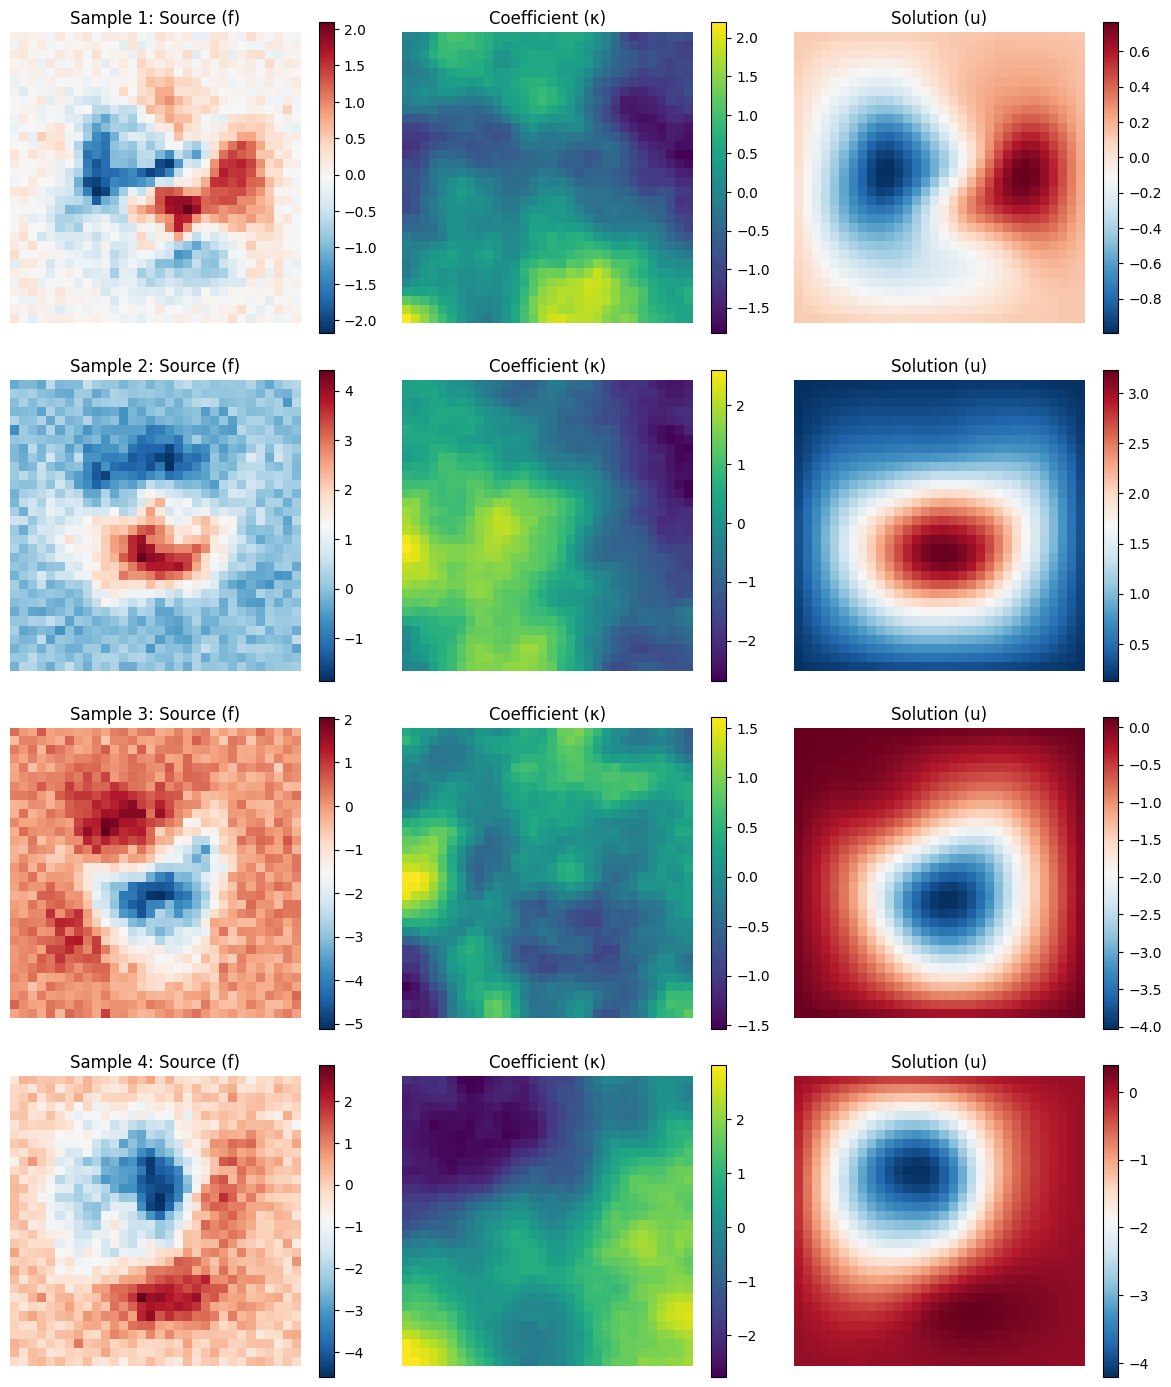


Data statistics:
  Solution range: [-4.210, 3.302]
  Source range: [-5.297, 5.271]
  Coefficient range: [-4.335, 2.994]


In [4]:
# Get a batch of data
batch = next(iter(train_loader))
u_batch = batch['u']  # Solutions (targets)
f_batch = batch['f']  # Conditions (source + coefficient)

print(f"Batch shapes:")
print(f"  u (solutions): {u_batch.shape}")  # (batch_size, 1, H, W)
print(f"  f (conditions): {f_batch.shape}") # (batch_size, 2, H, W)

# Visualize first 4 samples
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i in range(min(4, u_batch.shape[0])):
    # Extract data for this sample
    u = u_batch[i, 0].numpy()      # (H, W) - solution
    source = f_batch[i, 0].numpy() # (H, W) - source term
    coeff = f_batch[i, 1].numpy()  # (H, W) - coefficient
    
    # Plot source term
    im1 = axes[i, 0].imshow(source, cmap='RdBu_r')
    axes[i, 0].set_title(f'Sample {i+1}: Source (f)')
    axes[i, 0].axis('off')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # Plot coefficient
    im2 = axes[i, 1].imshow(coeff, cmap='viridis')
    axes[i, 1].set_title(f'Coefficient (κ)')
    axes[i, 1].axis('off')
    plt.colorbar(im2, ax=axes[i, 1])
    
    # Plot solution
    im3 = axes[i, 2].imshow(u, cmap='RdBu_r')
    axes[i, 2].set_title(f'Solution (u)')
    axes[i, 2].axis('off')
    plt.colorbar(im3, ax=axes[i, 2])

plt.tight_layout()
plt.show()

print(f"\nData statistics:")
print(f"  Solution range: [{u_batch.min():.3f}, {u_batch.max():.3f}]")
print(f"  Source range: [{f_batch[:, 0].min():.3f}, {f_batch[:, 0].max():.3f}]")
print(f"  Coefficient range: [{f_batch[:, 1].min():.3f}, {f_batch[:, 1].max():.3f}]")

## 4. Create Flow Matching Model

We use a **UNet architecture** with modern improvements for flow matching:

### Why U-Net for 2D PDEs? 
- **Spatial structure preservation** - PDEs have strong spatial correlations
- **Multi-scale features** - Captures both local and global patterns
- **Proven for diffusion models** - Flow matching and diffusion share similarities

### Model Improvements (Following Best Practices)
1. **Fourier Time Embeddings** - Sinusoidal features instead of linear (from DDPM/diffusion models)
2. **Self-Attention at Bottleneck** - Captures global spatial dependencies
3. **Residual Time Conditioning** - Better gradient flow

These improvements are **standard in flow matching literature** for spatial problems!

In [5]:
# Model configuration
# Data format: f_batch has shape (batch, 2, H, W) and u_batch has shape (batch, 1, H, W)
grid_size = u_batch.shape[2]  # Height (assuming square grid)
solution_dim = u_batch.shape[1] * grid_size * grid_size  # 1 * H * W
condition_dim = f_batch.shape[1] * grid_size * grid_size # 2 * H * W

print(f"Grid size: {grid_size}x{grid_size}")
print(f"Solution dimension: {solution_dim}")
print(f"Condition dimension: {condition_dim}")

# Create improved UNet model with Fourier time embeddings and attention
model = UNet(
    input_dim=solution_dim + condition_dim,  # Concatenated input
    base_ch=64,
    time_dim=1,              # Raw time (will be Fourier-embedded internally)
    use_attention=True       # Self-attention at bottleneck for global context
)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {num_params:,}")
print(f"\nModel improvements:")
print("  ✓ Fourier time embeddings (sinusoidal features)")
print("  ✓ Self-attention at bottleneck (global spatial reasoning)")
print("  ✓ Residual time conditioning at each layer")

Grid size: 32x32
Solution dimension: 1024
Condition dimension: 2048

Model parameters: 35,485,313

Model improvements:
  ✓ Fourier time embeddings (sinusoidal features)
  ✓ Self-attention at bottleneck (global spatial reasoning)
  ✓ Residual time conditioning at each layer


## 5. Create Flow and Trainer

We use Flow Matching with linear interpolation paths

In [6]:
# Create Flow Matching instance
flow = FlowMatching(
    model=model,
    path='linear',  # Can also use 'conditional_optimal_transport'
    sigma=0.0
)

# Create optimizer
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Create learning rate scheduler
epochs = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Create trainer
trainer = FlowMatchingTrainer(
    flow=flow,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device
)

print("Flow Matching Trainer created successfully!")
print(f"Configuration: {trainer.get_flow_config()}")

Flow Matching Trainer created successfully!
Configuration: {'flow_type': 'flow_matching', 'path': 'linear', 'sigma': 0.0}


## 6. Train the Model

Train using the flow matching algorithm

In [7]:
# Training configuration
save_dir = '../results/training/poisson_forward_notebook'

print("Starting training...")
print("=" * 60)

# Train the model
trainer.train(
    data_loader=train_loader,
    epochs=epochs,
    print_stats_interval=5,
    save_interval=10,
    save_dir=save_dir
)

print("\nTraining complete!")

Starting training...
Epoch: 0001/50 | Train_Loss: 2.384615 | LR: 9.99e-05 | Time: 8.359401
Epoch: 0006/50 | Train_Loss: 1.382661 | LR: 9.65e-05 | Time: 0.142492
Epoch: 0011/50 | Train_Loss: 1.051871 | LR: 8.85e-05 | Time: 0.210788
Epoch: 0016/50 | Train_Loss: 0.894287 | LR: 7.68e-05 | Time: 0.158727
Epoch: 0021/50 | Train_Loss: 0.76419 | LR: 6.24e-05 | Time: 0.142551
Epoch: 0026/50 | Train_Loss: 0.508312 | LR: 4.69e-05 | Time: 0.136024
Epoch: 0031/50 | Train_Loss: 0.597496 | LR: 3.16e-05 | Time: 0.275143
Epoch: 0036/50 | Train_Loss: 0.409955 | LR: 1.81e-05 | Time: 0.142564
Epoch: 0041/50 | Train_Loss: 0.442785 | LR: 7.78e-06 | Time: 0.244639
Epoch: 0046/50 | Train_Loss: 0.592049 | LR: 1.57e-06 | Time: 0.185448
Saved loss curve to ../results/training/poisson_forward_notebook/training_curve.png

Best loss: 0.291904
Best model saved to: ../results/training/poisson_forward_notebook/best_model.pt

Training complete!


## 7. Generate Samples Using ODE Solvers

We use **ODEFlowSolver** from `flowpde.solvers.ode_solvers` instead of manual integration:
- **Adaptive methods** (dopri5, dopri8, tsit5) - automatically adjust step size for accuracy
- **Fixed-step methods** (euler, midpoint, rk4) - predictable computation
- **Built on torchdiffeq** - battle-tested, efficient implementations

Using proper ODE solvers ensures numerical accuracy and efficiency!

In [8]:
# Set model to evaluation mode
model.eval()

# Get a test batch
test_batch = next(iter(train_loader))
true_solutions = test_batch['u'].to(device)
conditions = test_batch['f'].to(device)

# Create ODE solver for sampling
print("Creating ODE solver for inference...")
ode_solver = ODEFlowSolver(
    model=model,
    method='dopri5',  # Adaptive Runge-Kutta method
    rtol=1e-5,
    atol=1e-7
)

# Generate samples using the ODE solver
with torch.no_grad():
    # Sample from base distribution (noise)
    z = torch.randn_like(true_solutions).to(device)
    
    # Solve ODE from t=0 (noise) to t=1 (solution)
    generated_solutions = ode_solver.sample(
        condition=conditions,  
        x_init=z,             
        n_steps=50 
    )

print(f"Generated {generated_solutions.shape[0]} samples using {ode_solver.method} solver")
print(f"True solution range: [{true_solutions.min():.3f}, {true_solutions.max():.3f}]")
print(f"Generated solution range: [{generated_solutions.min():.3f}, {generated_solutions.max():.3f}]")

Creating ODE solver for inference...
Generated 10 samples using dopri5 solver
True solution range: [-4.210, 3.302]
Generated solution range: [-4.609, 3.296]


## 8. Visualize Results

Compare true solutions with generated samples

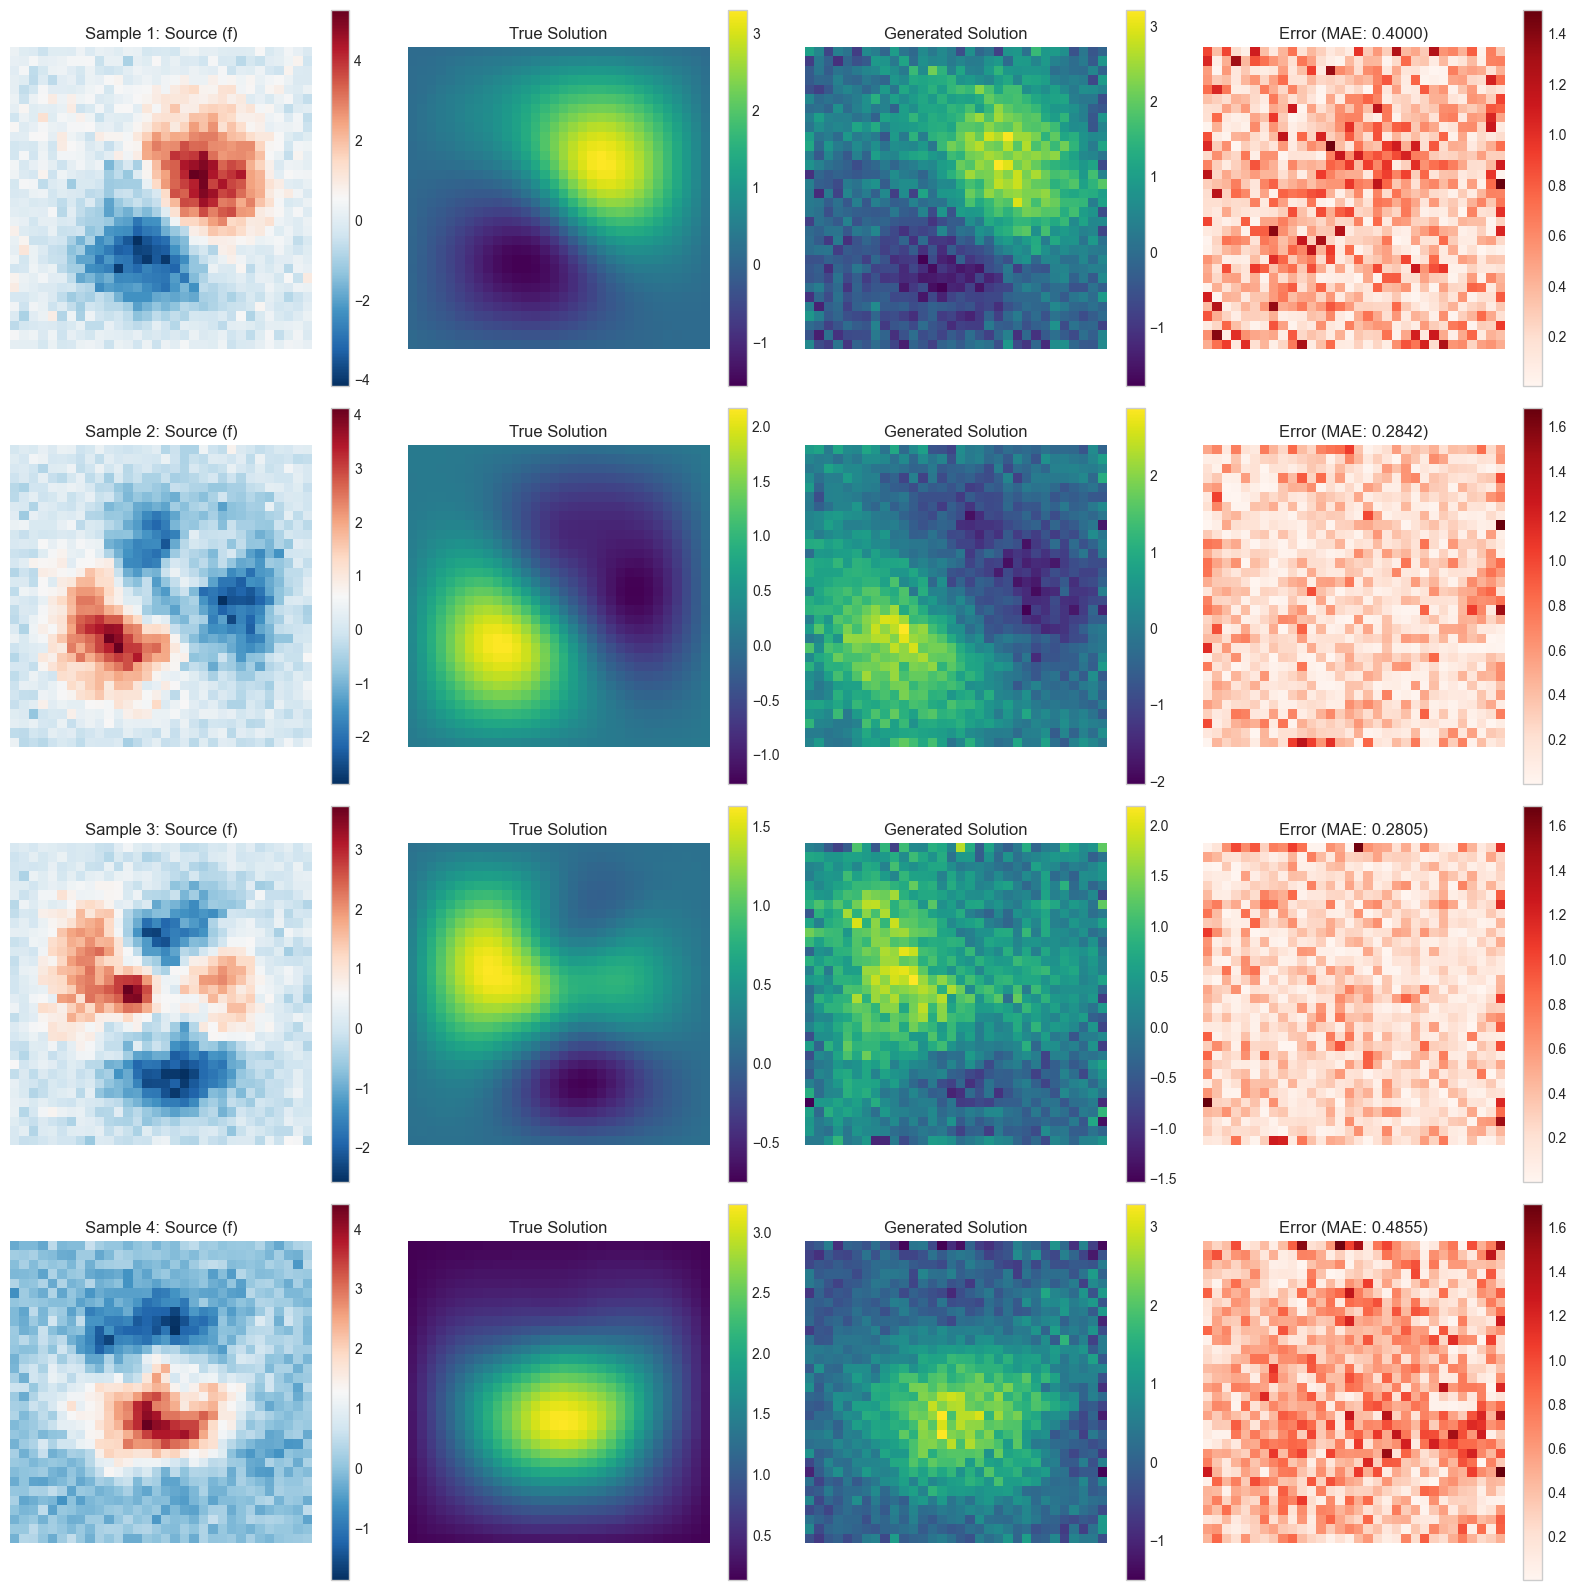


Metrics:
  MSE: 0.224483
  MAE: 0.360662


In [9]:
# Visualize comparison
num_samples = 4
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

for i in range(min(num_samples, conditions.shape[0])):
    # Get data
    source = conditions[i, 0].cpu().numpy()  # (H, W)
    coeff = conditions[i, 1].cpu().numpy()   # (H, W)
    true_sol = true_solutions[i, 0].cpu().numpy()  # (H, W)
    gen_sol = generated_solutions[i, 0].cpu().numpy()  # (H, W)
    error = np.abs(true_sol - gen_sol)
    
    # Plot source
    im1 = axes[i, 0].imshow(source, cmap='RdBu_r')
    axes[i, 0].set_title(f'Sample {i+1}: Source (f)')
    axes[i, 0].axis('off')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # Plot true solution
    im2 = axes[i, 1].imshow(true_sol, cmap='viridis')
    axes[i, 1].set_title('True Solution')
    axes[i, 1].axis('off')
    plt.colorbar(im2, ax=axes[i, 1])
    
    # Plot generated solution
    im3 = axes[i, 2].imshow(gen_sol, cmap='viridis')
    axes[i, 2].set_title('Generated Solution')
    axes[i, 2].axis('off')
    plt.colorbar(im3, ax=axes[i, 2])
    
    # Plot error
    im4 = axes[i, 3].imshow(error, cmap='Reds')
    axes[i, 3].set_title(f'Error (MAE: {error.mean():.4f})')
    axes[i, 3].axis('off')
    plt.colorbar(im4, ax=axes[i, 3])

plt.tight_layout()
plt.show()

# Compute metrics
mse = ((true_solutions - generated_solutions) ** 2).mean().item()
mae = (true_solutions - generated_solutions).abs().mean().item()

print(f"\nMetrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")

## 9. Compare Different ODE Solvers

Compare accuracy and speed of different ODE solvers

In [10]:
import time

# Test different solvers
solvers_to_test = ['euler', 'midpoint', 'rk4', 'dopri5']
solver_results = {}

# Use a single test sample
test_condition = conditions[:1]
test_true = true_solutions[:1]
test_noise = torch.randn_like(test_true).to(device)

print("Comparing ODE solvers...")
print("=" * 60)

for solver_name in solvers_to_test:
    # Create solver
    solver = ODEFlowSolver(
        model=model,
        method=solver_name,
        rtol=1e-5,
        atol=1e-7
    )
    
    # Generate sample and time it
    with torch.no_grad():
        start_time = time.time()
        # Correct signature: sample(condition, x_init, t_span, n_steps)
        generated = solver.sample(
            condition=test_condition,
            x_init=test_noise,
            n_steps=50
        )
        end_time = time.time()
    
    # Compute error
    mse = ((test_true - generated) ** 2).mean().item()
    mae = (test_true - generated).abs().mean().item()
    
    solver_results[solver_name] = {
        'mse': mse,
        'mae': mae,
        'time': end_time - start_time,
        'sample': generated
    }
    
    print(f"{solver_name:12s} | MSE: {mse:.6f} | MAE: {mae:.6f} | Time: {end_time - start_time:.4f}s")

print("=" * 60)
print(f"Best accuracy (MSE): {min(solver_results.items(), key=lambda x: x[1]['mse'])[0]}")
print(f"Fastest: {min(solver_results.items(), key=lambda x: x[1]['time'])[0]}")

Comparing ODE solvers...


/Users/sarperyurtseven/Desktop/sarper/.envs/pytorch/lib/python3.13/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Euler: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


euler        | MSE: 0.243199 | MAE: 0.387266 | Time: 3.9304s


/Users/sarperyurtseven/Desktop/sarper/.envs/pytorch/lib/python3.13/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Midpoint: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


midpoint     | MSE: 0.244200 | MAE: 0.388122 | Time: 0.8263s


/Users/sarperyurtseven/Desktop/sarper/.envs/pytorch/lib/python3.13/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: RK4: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


rk4          | MSE: 0.244200 | MAE: 0.388122 | Time: 1.3734s
dopri5       | MSE: 0.244200 | MAE: 0.388122 | Time: 0.4500s
Best accuracy (MSE): euler
Fastest: dopri5


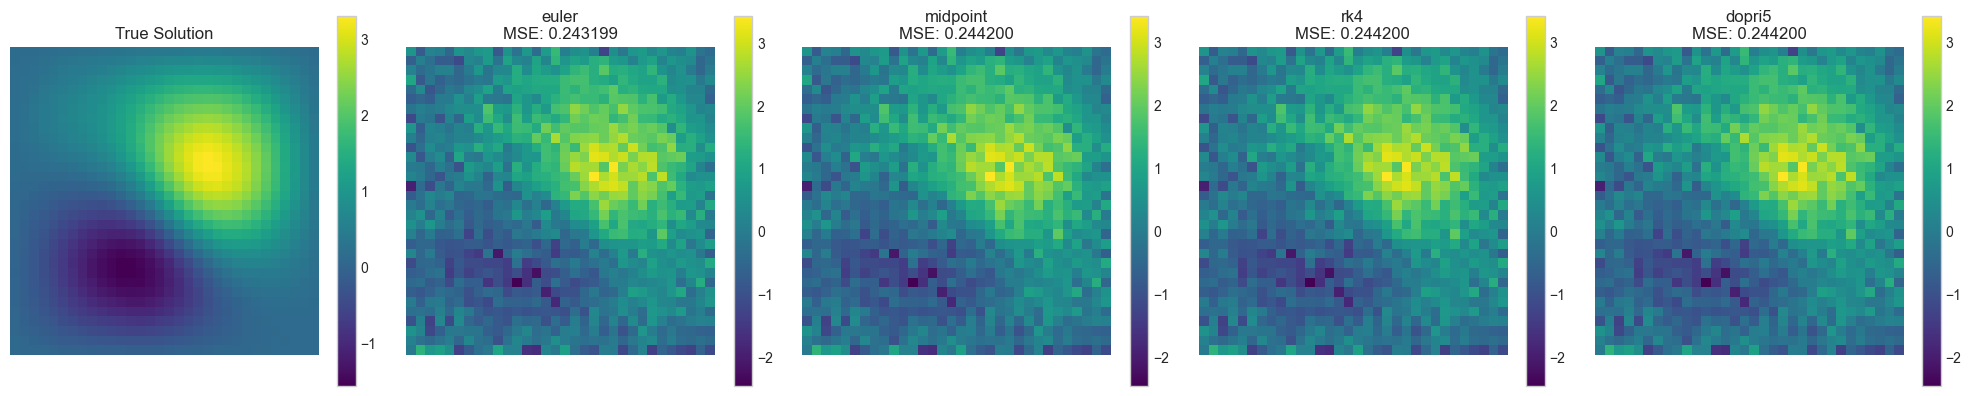

In [11]:
# Visualize solver comparison
fig, axes = plt.subplots(1, len(solvers_to_test) + 1, figsize=(4*(len(solvers_to_test)+1), 4))

# Plot true solution
im0 = axes[0].imshow(test_true[0, 0].cpu().numpy(), cmap='viridis')
axes[0].set_title('True Solution')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

# Plot each solver's result
for idx, solver_name in enumerate(solvers_to_test):
    sample = solver_results[solver_name]['sample']
    mse = solver_results[solver_name]['mse']
    mae = solver_results[solver_name]['mae']
    
    im = axes[idx + 1].imshow(sample[0, 0].cpu().numpy(), cmap='viridis')
    axes[idx + 1].set_title(f'{solver_name}\nMSE: {mse:.6f}')
    axes[idx + 1].axis('off')
    plt.colorbar(im, ax=axes[idx + 1])

plt.tight_layout()
plt.show()

## 10. Sample Multiple Solutions (Uncertainty Quantification)

Generate multiple samples for the same condition to visualize uncertainty

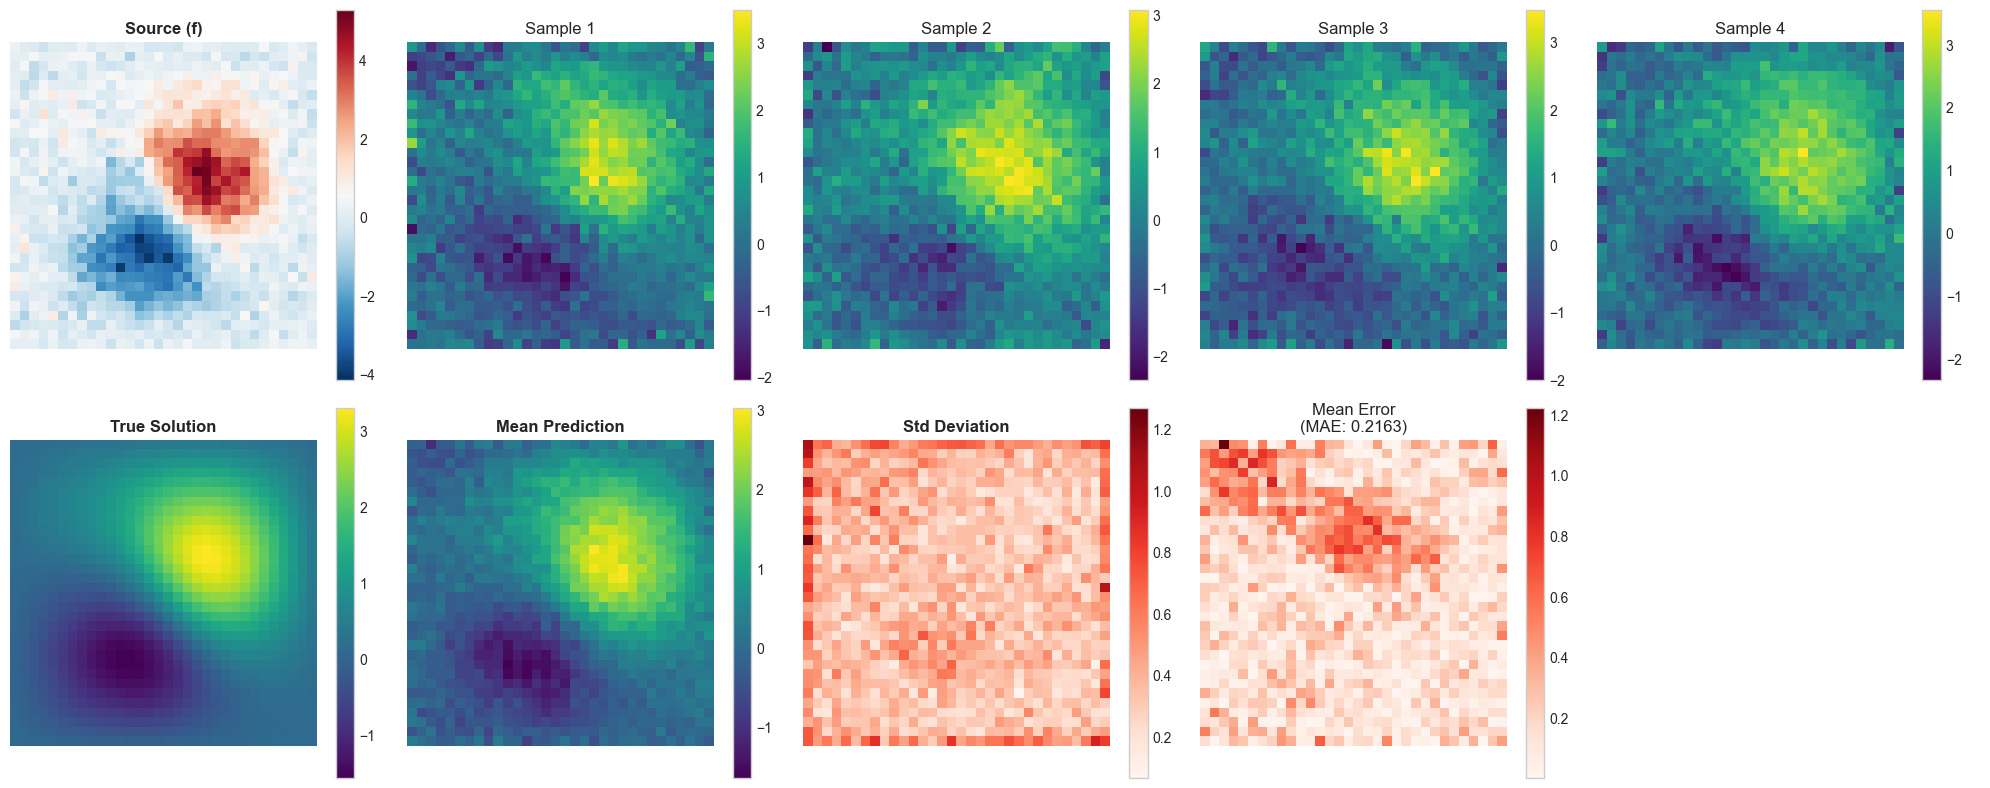


Uncertainty Quantification (from 8 samples):
  Mean prediction MAE: 0.216279
  Average std: 0.374812
  Max std: 1.268288


In [12]:
# Select one condition
idx = 0
single_condition = conditions[idx:idx+1]
true_solution = true_solutions[idx:idx+1]

# Generate multiple samples using the ODE solver
num_samples_uq = 8
samples = []

with torch.no_grad():
    for _ in range(num_samples_uq):
        # Sample different initial noise
        z = torch.randn_like(true_solution)
        
        # Use ODE solver to generate sample
        generated = ode_solver.sample(
            condition=single_condition,
            x_init=z,
            n_steps=50
        )
        
        samples.append(generated.cpu().numpy())

samples = np.array(samples).squeeze()  # (num_samples, H, W) or (num_samples, 1, H, W)

# Handle potential shape issues
if samples.ndim == 4:
    samples = samples[:, 0]  # Remove channel dimension: (num_samples, H, W)

# Compute statistics
mean_solution = samples.mean(axis=0)
std_solution = samples.std(axis=0)

# Visualize
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Plot source and true solution
source = single_condition[0, 0].cpu().numpy()  # (H, W)
coeff = single_condition[0, 1].cpu().numpy()   # (H, W)
true = true_solution[0, 0].cpu().numpy()       # (H, W)

im = axes[0, 0].imshow(source, cmap='RdBu_r')
axes[0, 0].set_title('Source (f)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im, ax=axes[0, 0])

im = axes[1, 0].imshow(true, cmap='viridis')
axes[1, 0].set_title('True Solution', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im, ax=axes[1, 0])

# Plot 4 random samples
for i in range(4):
    sample = samples[i]  # (H, W)
    im = axes[0, i+1].imshow(sample, cmap='viridis')
    axes[0, i+1].set_title(f'Sample {i+1}', fontsize=12)
    axes[0, i+1].axis('off')
    plt.colorbar(im, ax=axes[0, i+1])

# Plot mean and std
im = axes[1, 1].imshow(mean_solution, cmap='viridis')
axes[1, 1].set_title('Mean Prediction', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1])

im = axes[1, 2].imshow(std_solution, cmap='Reds')
axes[1, 2].set_title('Std Deviation', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2])

# Plot error of mean
error = np.abs(true - mean_solution)
im = axes[1, 3].imshow(error, cmap='Reds')
axes[1, 3].set_title(f'Mean Error\n(MAE: {error.mean():.4f})', fontsize=12)
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3])

# Hide last subplot
axes[1, 4].axis('off')

plt.tight_layout()
plt.show()

print(f"\nUncertainty Quantification (from {num_samples_uq} samples):")
print(f"  Mean prediction MAE: {np.abs(true - mean_solution).mean():.6f}")
print(f"  Average std: {std_solution.mean():.6f}")
print(f"  Max std: {std_solution.max():.6f}")